Daegu Apartment

Business Problem

Context
Goals: Menentukan harga sewa apartment yang tepat untuk setiap properti yang akan disewakan.

Analytic Approach: Analisis data untuk menemukan pola dan apa saja yang membedakan harga satu properti dengan properti lainnya.
Menggunakan model regresi untuk menyediakan alat memprediksi harga sewa apartment di Daegu untuk owners dan memberikan harga yang cukup adil untuk individuals dan bidders

Metric Evaluation: MSE, RMSE dan r2


 

<b> Contents </b>
1. Cleaning and Information
2. Data Preprocessing
3. Modelling
4. Conclusion
5. Recommendation

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('data_daegu_apartment.csv')
df.shape

(4123, 11)

### I. Cleaning & Information
Menelaah setiap isi dari setiap column, melihat apakah ada column yang missing dan mendapatkan informasi dari data dengan cara visualisasi dan statistik

In [5]:
df.info()
# Ga ada yg null, semua dtype nya udh keliatan, banyaknya sesuai dengan df.shape (4123 row, 11 column)

<class 'pandas.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   HallwayType                       4123 non-null   str    
 1   TimeToSubway                      4123 non-null   str    
 2   SubwayStation                     4123 non-null   str    
 3   N_FacilitiesNearBy(ETC)           4123 non-null   float64
 4   N_FacilitiesNearBy(PublicOffice)  4123 non-null   float64
 5   N_SchoolNearBy(University)        4123 non-null   float64
 6   N_Parkinglot(Basement)            4123 non-null   float64
 7   YearBuilt                         4123 non-null   int64  
 8   N_FacilitiesInApt                 4123 non-null   int64  
 9   Size(sqf)                         4123 non-null   int64  
 10  SalePrice                         4123 non-null   int64  
dtypes: float64(4), int64(4), str(3)
memory usage: 354.4 KB


In [ ]:
df.describe()
#Deskriptif statistik

,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice,LogSalePrice,age
count,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000,4123.000000
mean,1.930876,4.135338,2.746301,568.979141,2002.999757,5.817851,954.630851,221767.926995,12.173150,23.000243
std,2.198832,1.802640,1.496610,410.372742,8.905768,2.340507,383.805648,106739.839945,0.557027,8.905768
min,0.000000,0.000000,0.000000,0.000000,1978.000000,1.000000,135.000000,32743.000000,10.396475,11.000000
25%,0.000000,3.000000,2.000000,184.000000,1993.000000,4.000000,644.000000,144752.000000,11.882784,18.000000
50%,1.000000,5.000000,2.000000,536.000000,2006.000000,5.000000,910.000000,209734.000000,12.253600,20.000000
75%,5.000000,5.000000,4.000000,798.000000,2008.000000,7.000000,1149.000000,291150.000000,12.581597,33.000000
max,5.000000,7.000000,5.000000,1321.000000,2015.000000,10.000000,2337.000000,585840.000000,13.280804,48.000000


In [59]:
df['HallwayType'].value_counts(ascending=True)
#one-hot

HallwayType
corridor     464
mixed       1131
terraced    2528
Name: count, dtype: int64

In [7]:
df['TimeToSubway'].value_counts()
#ordinal

TimeToSubway
0-5min                1953
5min~10min             787
15min~20min            629
10min~15min            583
no_bus_stop_nearby     171
Name: count, dtype: int64

In [8]:
df['SubwayStation'].value_counts().sort_index()
#one-hot

SubwayStation
Bangoge                   502
Banwoldang                529
Chil-sung-market           74
Daegu                      65
Kyungbuk_uni_hospital    1152
Myung-duk                1044
Sin-nam                   467
no_subway_nearby          290
Name: count, dtype: int64

In [9]:
df['N_FacilitiesNearBy(ETC)'].value_counts().sort_index()
#leave as is

N_FacilitiesNearBy(ETC)
0.0    1828
1.0     631
2.0     330
5.0    1334
Name: count, dtype: int64

In [10]:
df['N_FacilitiesNearBy(PublicOffice)'].value_counts().sort_index()
#leave as is

N_FacilitiesNearBy(PublicOffice)
0.0      46
1.0     291
2.0     530
3.0     844
4.0     254
5.0    1252
6.0     451
7.0     455
Name: count, dtype: int64

In [11]:
df['N_SchoolNearBy(University)'].value_counts().sort_index()
#leave as is

N_SchoolNearBy(University)
0.0      97
1.0     833
2.0    1359
3.0     396
4.0     606
5.0     832
Name: count, dtype: int64

In [ ]:
df['N_Parkinglot(Basement)'].value_counts().sort_index()
#mngkn pake log

N_Parkinglot(Basement)
0.0       493
18.0       51
56.0       74
76.0       51
79.0      104
108.0      50
181.0     108
184.0     139
203.0     217
218.0      41
400.0      14
475.0     203
524.0     220
536.0     664
605.0     213
798.0     502
930.0     322
1174.0    159
1270.0    420
1321.0     78
Name: count, dtype: int64

In [ ]:
df['YearBuilt'].value_counts().sort_index()
#ganti ke age

YearBuilt
1978     49
1980      4
1985     51
1986    273
1992    326
1993    451
1997     67
2003      7
2005    502
2006    460
2007    853
2008    203
2009    171
2013    322
2014    292
2015     92
Name: count, dtype: int64

In [14]:
df['N_FacilitiesInApt'].value_counts().sort_index()
#leave as is

N_FacilitiesInApt
1       41
2       50
3      477
4     1001
5      810
7      838
8      203
9      159
10     544
Name: count, dtype: int64

In [ ]:
df['Size(sqf)'].value_counts().sort_index()
#mngkn pake log

Size(sqf)
135     19
138      2
156     16
160      1
163      1
        ..
1796    15
1928    34
2056    27
2092     8
2337    29
Name: count, Length: 89, dtype: int64

In [16]:
df['SalePrice'].value_counts().sort_index()
#pake log

SalePrice
32743     1
34070     1
34513     2
35398     4
35840     2
         ..
556637    1
557522    1
566371    2
570796    2
585840    1
Name: count, Length: 838, dtype: int64

#### Visualisasi untuk melihat pola
- Karena harga rumah yang sangat variatif, digunakan log1p (log(1+SalePrice)) sehingga distribusi harga lebih normal, mengurangi outlier dan membuat model lebih mudah mengerti perubahan harga dengan melihat persentase dan bukan harganya secara langsung
- Menggunakan Usia dan bukan tahun agar model lebih mudah memahami (bukan angka besar)
- Visualisasi dengan scatterplot untuk LogSalePrice VS Size (numeric vs numeric)
- Visualisasi dengan scatterplot dengan warna sebagai size, y-label sebagai LogSalePrice dan x-lable sebagai kategori numerik lainnya
- Visualisasi dengan boxplot untuk numeric vs category

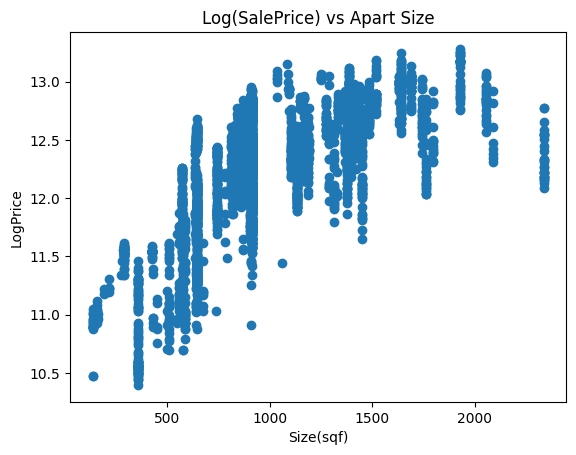

C:\Users\MyBook Hype\AppData\Local\Temp\ipykernel_26040\1273989651.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.82, 0.96])


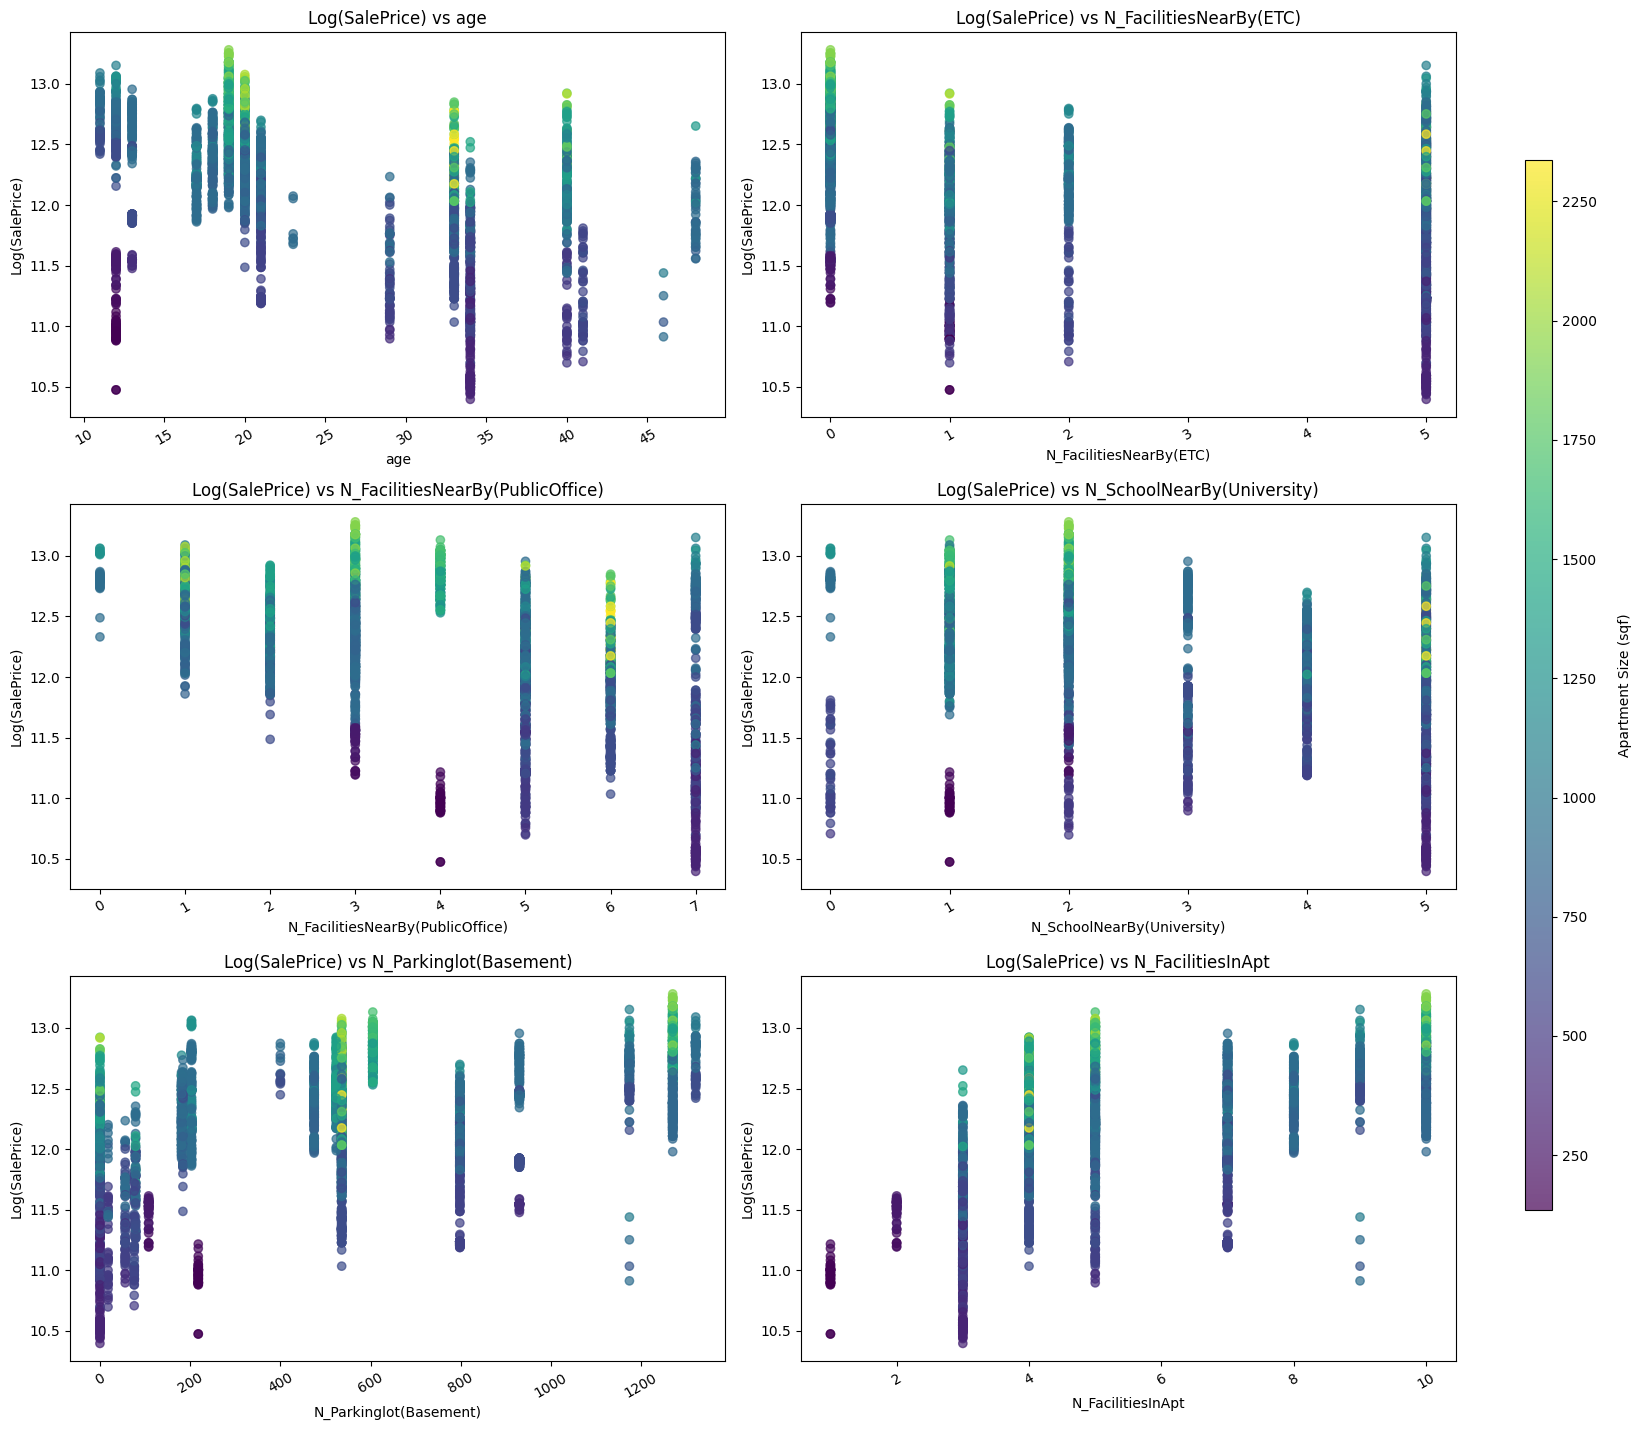

C:\Users\MyBook Hype\AppData\Local\Temp\ipykernel_26040\1273989651.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.82, 0.96])


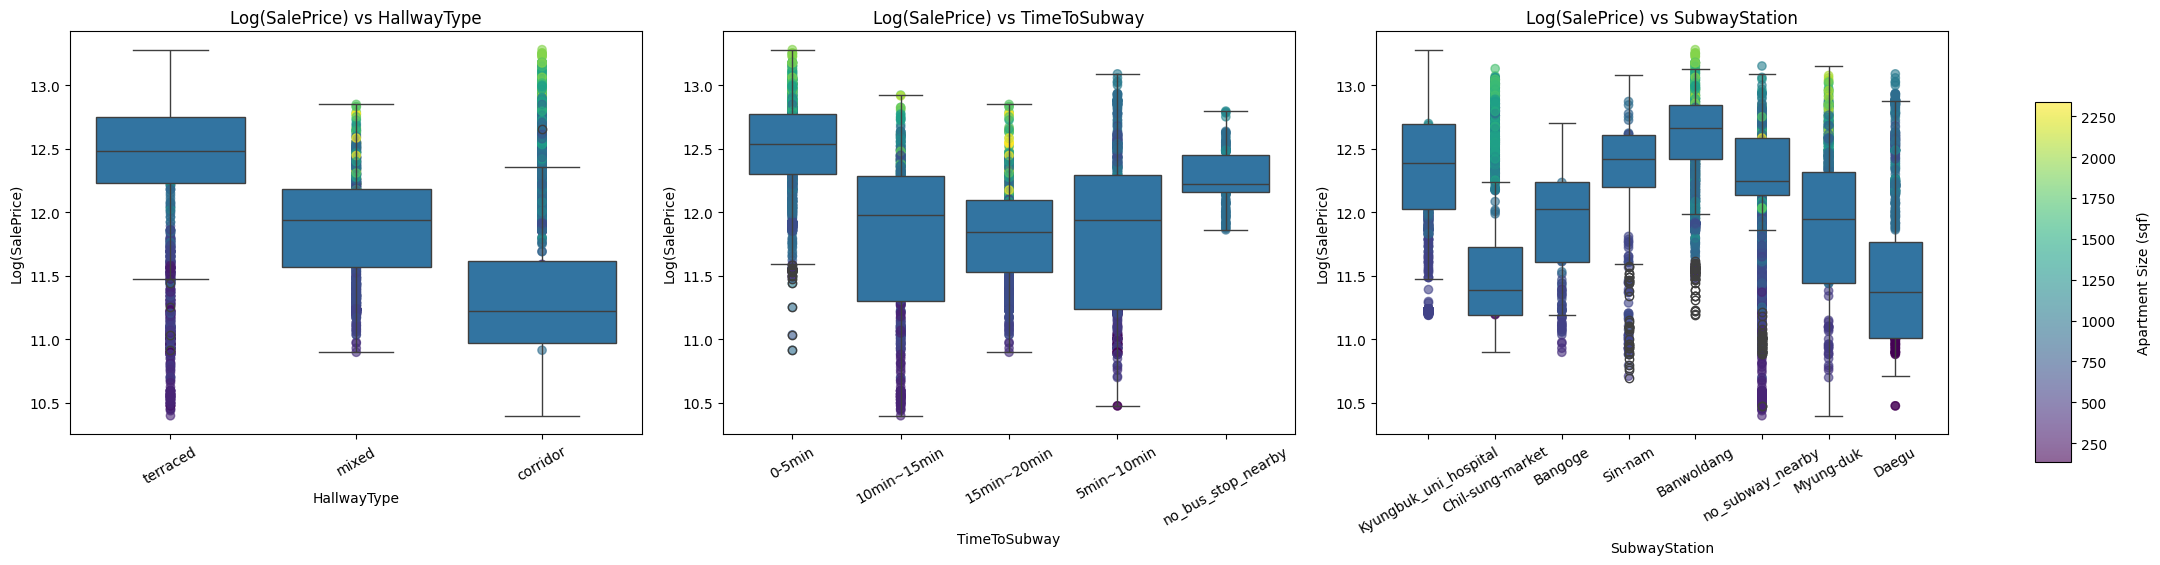

In [ ]:
df['age'] = 2026 - df['YearBuilt']
df['LogSalePrice'] = np.log1p(df['SalePrice'])

# Price vs Size
plt.scatter(df['Size(sqf)'],df['LogSalePrice'])
plt.xlabel('Size(sqf)')
plt.ylabel('LogPrice')
plt.title('Log(SalePrice) vs Apart Size')
plt.show()

numeric_cols = [
    'age',
    'N_FacilitiesNearBy(ETC)',
    'N_FacilitiesNearBy(PublicOffice)',
    'N_SchoolNearBy(University)',
    'N_Parkinglot(Basement)',
    'N_FacilitiesInApt'
]

categorical_cols = [
    'HallwayType',
    'TimeToSubway',
    'SubwayStation'
]

# Numeric
fig, axs = plt.subplots(3, 2, figsize=(18, 15))
axs = axs.flatten()

for i, col in enumerate(numeric_cols):
    sc = axs[i].scatter(
        df[col],
        df['LogSalePrice'],
        c=df['Size(sqf)'],
        alpha=0.7
    )
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Log(SalePrice)')
    axs[i].set_title(f'Log(SalePrice) vs {col}')
    axs[i].tick_params(axis='x', rotation=30)

fig.subplots_adjust(right=0.82)
cbar_ax = fig.add_axes([0.85, 0.15, 0.015, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Apartment Size (sqf)', rotation=90, labelpad=15)

plt.tight_layout(rect=[0, 0, 0.82, 0.96])
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(24, 6))

# Category
for i, col in enumerate(categorical_cols):
    sns.boxplot(x=df[col], y=df['LogSalePrice'], ax=axs[i])

    x_codes = df[col].astype('category').cat.codes
    sc = axs[i].scatter(
        x_codes,
        df['LogSalePrice'],
        c=df['Size(sqf)'],
        alpha=0.6
    )

    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Log(SalePrice)')
    axs[i].set_title(f'Log(SalePrice) vs {col}')
    axs[i].tick_params(axis='x', rotation=30)

fig.subplots_adjust(right=0.82)
cbar_ax = fig.add_axes([0.85, 0.18, 0.015, 0.6])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Apartment Size (sqf)', rotation=90, labelpad=15)

plt.tight_layout(rect=[0, 0, 0.82, 0.96])
plt.show()

Di Log(SalePrice) vs Size:
- Skew ke kiri
- Harga lebih mahal kalau apart lebih besar

Di Log(SalePrice) vs Age:
-Apart yang sangat tua (>45 tahun): ukurannya cukup besar 750-1000sqf dgn harga yg masih cukup mahal
- Apart berukuran besar tidak terlalu banyak dijual dan harga nya masih mahal tetapi yg paling mahal bukan yg paling besar
- Apart <750 sqf dan 750-1000sqf banyaknya cukup seimbang
- Kebanyakan apart berukuran <750sqf masih relatif baru dengan harga yang lebih mahal
- <b> Kesimpulan: Usia Apart tidak terlalu berpengaruh terhadap harga namun cenderung apart dengan usia < 22 tahun memiliki harga yang lebih mahal </b>

Di Log(SalePrice) vs ETC
- Apart yg besar dan mahal tidak selalu memiliki fasilitas yang lebih banyak (masih cukup sama untuk semua kalangan)
- <b> Kesimpulan: Tidak terlalu menunjukkan korelasi yang bermanfaat </b>

Di Log(SalePrice) vs PublicOffice
- Apart berukuran sedang dan mahal tidak ada public office
- Apart kecil memberikan lebih banyak fasilitas public office
- <b> Kesimpulan: Tidak terlalu menunjukkan korelasi yang bermanfaat </b>

Di Log(SalePrice) vs University
- Apart yang sangat besar biasa berada di lokasi yang dikelilingi banyak universitas
- <b> Kesimpulan: Apart yang besar dan mahal cenderung berada di sekitar Universitas </b>

Di PublicOffice dan University menunjukkan beberapa apart tidak yang mahal dan ukuran sedang mungkin dimiliki bukan oleh kalangan mahasiswa atau usia produktif

Di Log(SalePrice) vs ParkingLot
- Lebih banyak apart tidak memiliki basement (lebih memilih transport station yang dekat sepertinya)
- Lebih banyak harga apart yang mahal bila memiliki parkinglot luas (premium resident sepertinya)
- <b> Kesimpulan: Parkinglot tidak terlalu menjadi masalah dalam memilih apart dan apart yang mahal cenderung memiliki parkinglot luas </b>

Di Log(SalePrice) vs FacilitiesinAPT
- Fasilitias apartment lebih menentukan kemahalan suatu apart
- <b> Kesimpulan: Lebih banyak fasilitas sangat berkolerasi dengan harga apart </b>

Di Log(SalePrice) vs HallwayType
- Apart lebih besar memiliki koridor dan mixed dengan harga yang lebih mahal dengan bias yang sangat besar
- <b> Kesimpulan: Terdapat korelasi antara tipe Hallway dengan harga apart </b>

Di Log(SalePrice) vs TimeToSubway
- Apart yang lebih besar dan mahal cukup dekat dengan Subway (<15min)
- 15-20min sangat seimbang untuk harga mahal dan murah
- Apart yang lebih kecil cenderung sangat dekat dengan subway (<10min)
- Beberapa apart menengah tidak memiliki busstop (mungkin daerah yang lebih asri)
- <b> Kesimpulan: Terdapat korelasi antara harga apart dengan dekatnya ke subway </b>

Di Log(SalePrice) vs SubwayStation
- Kawasan apart besar dan mahal berada dekat Kyungbuk_uni_hospital, Sin-nam, banwoldang dan Myung-duk
- <b> Kesimpulan: Terdapat korelasi antara SubwayStation tertentu dengan harga apart </b>

<b> Kesimpulan secara keseluruhan: Size, Subway station, Hallway, Time to Subway, Parkinglot, University, Facilities in apt dan age memiliki korelasi yang cukup besar dengan harga apart </b>

#### Melihat data secara statistik melalui distribusi dan tes parametrik untuk melihat signifikansi
- Menggunakan skew untuk melihat distribusi data
- Menggunakan Korelasi Spearman untuk melihat korelasi data numerik dengan distribusi yang tidak linear
    - Dilanjutkan dengan Tukey HSD untuk melihat per kategori dari column category
- Menggunakan ANOVA untuk 3+ independent categoric group vs numeric

In [ ]:
from scipy.stats import f_oneway

df['LogSalePrice'] = np.log1p(df['SalePrice'])
df['age'] = 2026 - df['YearBuilt']

# Melihat distribusi dengan skewness
print("Original SalePrice skewness:", df['SalePrice'].skew())
print("LogSalePrice skewness:", df['LogSalePrice'].skew())

#Spearman
corr_matrix = df[numeric_cols].corr(method='spearman')
print("\nSpearman Correlation with LogSalePrice:")
print(corr_matrix['LogSalePrice'].sort_values(ascending=False))

#ANOVA
for col in ['HallwayType', 'TimeToSubway', 'SubwayStation']:
    groups = [group['LogSalePrice'].values for name, group in df.groupby(col)]
    f_stat, p_value = f_oneway(*groups)
    print(f"\n{col}:")
    print(f"F-statistic = {f_stat:.4f}")
    print(f"p-value = {p_value:.10e}")

Original SalePrice skewness: 0.4523214920387305
LogSalePrice skewness: -0.6791479057421512

Spearman Correlation with LogSalePrice:
LogSalePrice                        1.000000
Size(sqf)                           0.704138
N_FacilitiesInApt                   0.519243
N_Parkinglot(Basement)              0.433011
N_SchoolNearBy(University)         -0.392807
N_FacilitiesNearBy(PublicOffice)   -0.482899
age                                -0.494631
N_FacilitiesNearBy(ETC)            -0.506539
Name: LogSalePrice, dtype: float64

HallwayType:
F-statistic = 2434.5723
p-value = 0.0000000000e+00

TimeToSubway:
F-statistic = 556.2774
p-value = 0.0000000000e+00

SubwayStation:
F-statistic = 200.3537
p-value = 1.6297982096e-256


<b> Distribution </b>
- Hasil Skewness SalePrice = 0.45 yang menunjukkan skew ke kanan sedikit
- Hasil Skewness LogSalePrice = -0.68 yang menunjukkan skew ke kiri
<b> Kesimpulan: Menggunakan SalePrice saja lebih baik dibandingkan LogSalePrice. Kemungkinan tidak memerlukan untuk menggunakan LogSalePrice (Akan dibuktikan lewat modelling nantinya) </b>

<b> Spearman Correlation </b>
- Size = 0.704 (korelasi positif)
- Facilities in Apt = 0.519 (korelasi positif)
- Parkinglot = 0.433 (korelasi positif)
- Age = -0.495 (korelasi negatif)
- ETC = -0.507 (korelasi negatif: mungkin lingkungan lebih pedesaan?)
- Public Office = -0.483 (korelasi negatif: mungkin lebih distrik komersial, pedesaan, dll)
- Universitas = -0.393 (korelasi negatif: lebih murah untuk mahasiswa)

<b> ANOVA </b>
- Seluruh kategori memiliki hasil p<0.001 yang menunjukkan perbedaan yang signifikan secara statistik pada ketiga kategori tersebut dengan harga apart

<b> KESIMPULAN </b>
- Yang secara signifikan mempengaruhi harga apart adalah size, facilities in apt, parking lot dan age
- Semua hasil kategorik secara statistik mempengaruhi harga apart
- Perbedaan dari korelasi secara visualisasi dan statistik hanya ada pada Universitas

Dilanjut dengan Tukey HSD untuk menspesifikasikan kategori secara signifikan

In [62]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_hall = pairwise_tukeyhsd(
    endog=df['LogSalePrice'],
    groups=df['HallwayType'],
    alpha=0.05
)

tukey_time = pairwise_tukeyhsd(
    endog=df['LogSalePrice'],
    groups=df['TimeToSubway'],
    alpha=0.05
)

print(tukey_hall)
print(tukey_time)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1   group2  meandiff p-adj lower  upper  reject
-----------------------------------------------------
corridor    mixed   0.5922   0.0 0.5434 0.6409   True
corridor terraced   1.1883   0.0 1.1436 1.2329   True
   mixed terraced   0.5961   0.0 0.5645 0.6278   True
-----------------------------------------------------
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1         group2       meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
     0-5min        10min~15min     -0.7    0.0 -0.7578 -0.6422   True
     0-5min        15min~20min   -0.673    0.0 -0.7292 -0.6168   True
     0-5min         5min~10min  -0.6509    0.0 -0.7027 -0.5992   True
     0-5min no_bus_stop_nearby  -0.2443    0.0 -0.3421 -0.1466   True
10min~15min        15min~20min    0.027 0.8343 -0.0435  0.0974  False
10min~15min         5min~10min   0.0491  0.266 -0.0179   0.116

Hasil:

<b> HallwayType </b>
- Setiap tipe hallway memberikan hasil avg price yang berbeda

<b> TimeToSubway </b>
- Untuk beberapa orang dekat dengan Subway sangat penting namun lebih dari 5 menit dan tidak ada bus stop tidak terlalu menunjukkan perbedaan statistik

Subway station tidak dilakukan karena terlalu banyak

#### OUTLIERS (Boxplot & IQR)
Yang mahal dan luxurious sekali, yang murah di ujung sekali (mungkin)

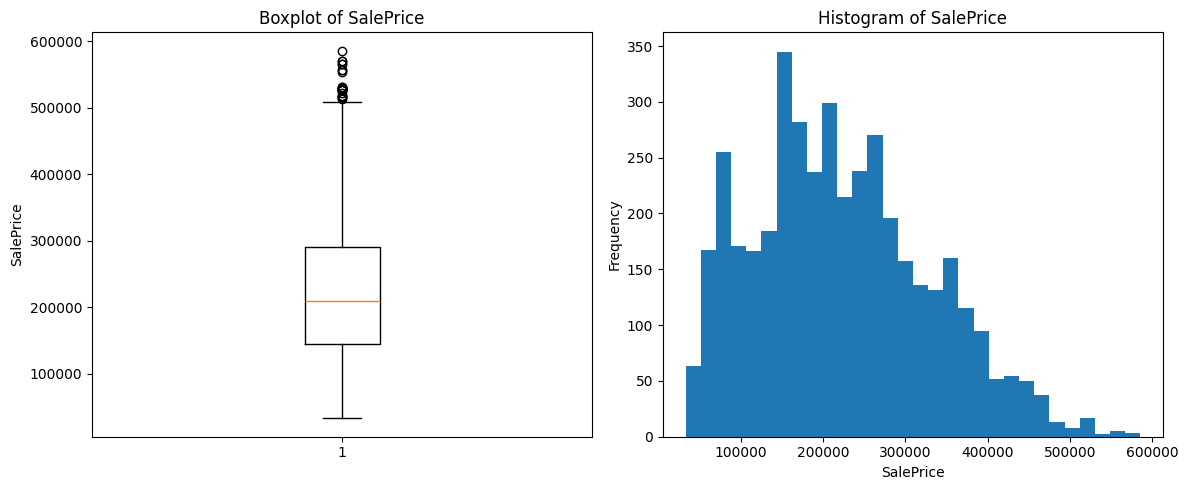

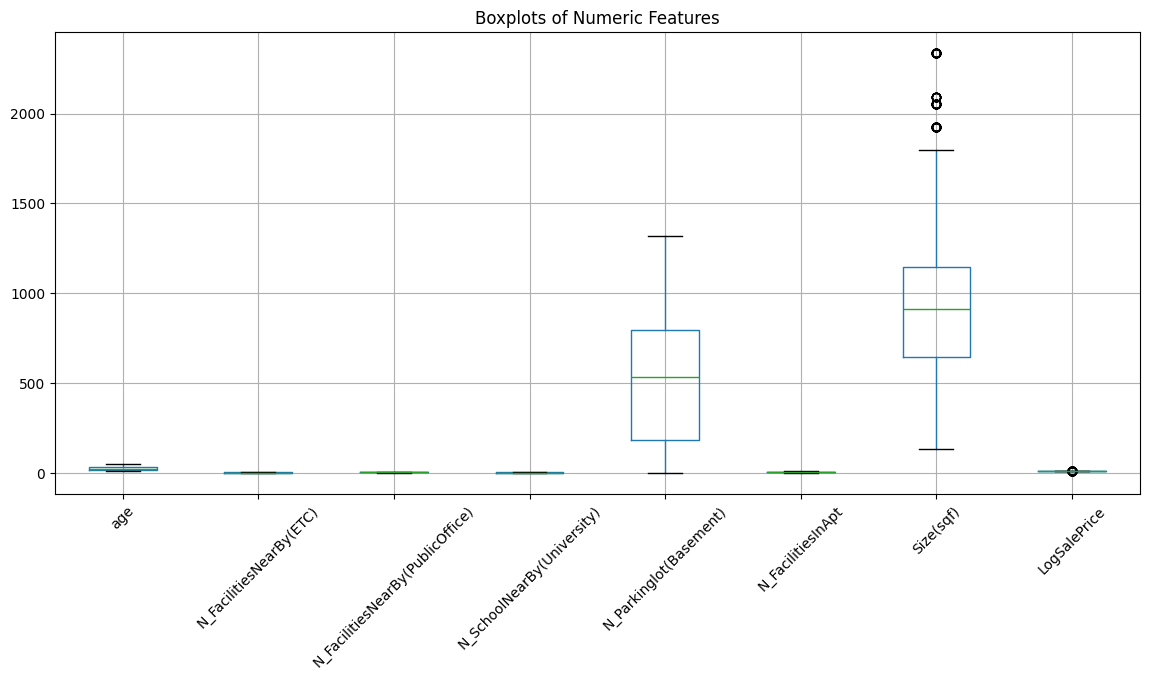

age: 0 outliers
N_FacilitiesNearBy(ETC): 0 outliers
N_FacilitiesNearBy(PublicOffice): 0 outliers
N_SchoolNearBy(University): 0 outliers
N_Parkinglot(Basement): 0 outliers
N_FacilitiesInApt: 0 outliers
Size(sqf): 98 outliers
LogSalePrice: 63 outliers


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].boxplot(df['SalePrice'])
axs[0].set_title('Boxplot of SalePrice')
axs[0].set_ylabel('SalePrice')

axs[1].hist(df['SalePrice'], bins=30)
axs[1].set_title('Histogram of SalePrice')
axs[1].set_xlabel('SalePrice')
axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

df[numeric_cols].boxplot(figsize=(14, 6), rot=45)
plt.title('Boxplots of Numeric Features')
plt.show()

#IQR (Interquartile Range)
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

for col in numeric_cols:
    print(f"{col}: {count_outliers_iqr(df[col])} outliers")

Hasil: Outlier ditemukan di Size dan SalePrice dikarenakan apart yang luxurious cenderung memiliki harga yang sangat tinggi. Outliers ini tetap dipertahankan namun kemungkinan tree model menunjukkan hasil yang lebih bagus dibandingkan dengan ANN keras yang tidak di skala dengan baik dan dapat membuat error bila menggunakan RMSE

In [18]:
df.head()

,HallwayType,TimeToSubway,SubwayStation,N_FacilitiesNearBy(ETC),N_FacilitiesNearBy(PublicOffice),N_SchoolNearBy(University),N_Parkinglot(Basement),YearBuilt,N_FacilitiesInApt,Size(sqf),SalePrice
0,terraced,0-5min,Kyungbuk_uni_hospital,0.0,3.0,2.0,1270.0,2007,10,1387,346017
1,terraced,10min~15min,Kyungbuk_uni_hospital,1.0,5.0,1.0,0.0,1986,4,914,150442
2,mixed,15min~20min,Chil-sung-market,1.0,7.0,3.0,56.0,1997,5,558,61946
3,mixed,5min~10min,Bangoge,5.0,5.0,4.0,798.0,2005,7,914,165486
4,terraced,0-5min,Sin-nam,0.0,1.0,2.0,536.0,2006,5,1743,311504


#### II. Preprocessing:
1. Convert ke Numeric (one-hot, ordinal), log dan drop year (ganti supaya lebih gampang dilihat machine)
2. Split data untuk test & training + pisahin price di y dan x ga boleh ada price
3. Training & Test (100 data dulu): Fit pakai regression (Ridge regression/SVR Linear atau SVR rbf/Ensemble Regressor) Linear --> SVR --> RandomForestRegression/ XGBoost / ANN Keras
Pemilihan regression karena memprediksi kuantitas, dengan sample <100k dan hampir seluruh fitur penting itu dimasukan kedalam model
- https://doi.org/10.3390/analytics3010003
- https://www.mdpi.com/2076-3417/14/20/9528
- https://medium.com/analytics-vidhya/house-rental-the-data-science-way-part-2-train-a-regression-model-tpot-and-auto-ml-9cdb5cb4b1b4
- https://towardsdev.com/predict-house-prices-5x-faster-with-lightgbm-vs-xgboost-d5eb01ea0614
4. Tambah early stopping untuk cegah overfitting kalau evaluation metrics tertentu stop improving
5. Hyperparameter (apa saja??) pakai gridsearchCV
6. Evaluate dgn regression metrics: MAE, MSE, RMSE, R2, MAPE, scoring prediction
- https://farshadabdulazeez.medium.com/essential-regression-evaluation-metrics-mse-rmse-mae-r%C2%B2-and-adjusted-r%C2%B2-0600daa1c03a
7. Visualisasi predicted vs actual plot, residual plot, feature importance
8. Save and LOAD

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV

#### III. Modelling
<b> RF & XGBoost </b>
1.

<b> ANN KERAS </b>
1. Create model using create_model()
2. Setup Tensorboard callback using create_tensorflow_callback()
3. Call fit() passing it the training data, validation data, number of epochs to train from (NUM_EPOCHS)
4. Return the Model
5. Confusion metrics

#### IV. Conclusion

#### V. Recommendation
1. ANN Keras biasa digunakan untuk gambar, mungkin hasil akan lebih baik tergantung gambar dari apart juga